In [2]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier  # Example model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

In [3]:
root_dir = 'C:/Users/MELİSA/smaller_dataset.csv'
df = pd.read_csv(root_dir)

In [4]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack_Type
0,192.168.137.144-192.168.137.240-49153-13217-6,192.168.137.144,49153,192.168.137.240,13217,6,05/08/2022 10:53:38 AM,18188538,1,4,...,0.0,0.0,0.0,0.0,5.838632e+06,755017.935929,6473349.0,5003680.0,NeedManualLabel,DoS_DoS SYN Flood
1,192.168.137.65-192.168.137.171-7661-6668-6,192.168.137.65,7661,192.168.137.171,6668,6,26/10/2022 11:53:56 AM,99736150,2,0,...,0.0,0.0,0.0,0.0,9.973615e+07,0.000000,99736150.0,99736150.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation
2,192.168.137.12-192.168.137.235-15376-8008-6,192.168.137.12,15376,192.168.137.235,8008,6,26/10/2022 03:46:03 PM,88834040,2,0,...,0.0,0.0,0.0,0.0,8.883404e+07,0.000000,88834040.0,88834040.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation
3,192.168.137.12-192.168.137.206-21499-55442-6,192.168.137.12,21499,192.168.137.206,55442,6,26/10/2022 04:50:41 PM,17797062,1,1,...,0.0,0.0,0.0,0.0,1.779706e+07,0.000000,17797062.0,17797062.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation
4,192.168.137.225-192.168.137.132-38616-8080-6,192.168.137.225,38616,192.168.137.132,8080,6,14/09/2022 11:10:19 AM,294063,1,1,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,NeedManualLabel,DDoS_DDoS-HTTP Flood


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'],  format='%d/%m/%Y %I:%M:%S %p')

In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)  # Otomatik ekran genişliği

In [7]:
df_sorted = df.sort_values(by='Timestamp')
df_sorted.iloc[30000:30010]

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack_Type
20561,192.168.137.195-192.168.137.196-52813-1080-17,192.168.137.195,52813,192.168.137.196,1080,17,2022-08-10 14:45:30,118888059,16,3,1920.0,30.0,120.0,120.0,120.0,0.0,10.0,10.0,10.0,0.0,16.401984,0.159814,6.604892e+06,3.515145e+06,14733951.0,536044.0,118352015.0,7.890134e+06,2.285469e+06,14733951.0,4135432.0,55440915.0,2.772046e+07,3.324555e+07,51228613.0,4212302.0,0,0,0,0,128,24,0.134580,0.025234,10.0,120.0,103.500000,40.298230,1623.947368,0,0,0,0,0,0,0,0,0.0,108.947368,120.0,10.0,0,0,0,0,0,0,1,128,0,2,0,0,15,8,4.760722e+06,0.000000e+00,4760722.0,4760722.0,8.113664e+06,2.144971e+06,14733951.0,6392559.0,NeedManualLabel,DoS_DoS-UDP_Flood
38645,192.168.137.195-192.168.137.196-62214-1080-17,192.168.137.195,62214,192.168.137.196,1080,17,2022-08-10 14:45:31,118608178,16,3,1920.0,30.0,120.0,120.0,120.0,0.0,10.0,10.0,10.0,0.0,16.440688,0.160191,6.589343e+06,3.553162e+06,14802608.0,419485.0,118608178.0,7.907212e+06,2.324956e+06,14802608.0,4130410.0,41100654.0,2.055033e+07,1.909508e+07,34052586.0,7048068.0,0,0,0,0,128,24,0.134898,0.025293,10.0,120.0,103.500000,40.298230,1623.947368,0,0,0,0,0,0,0,0,0.0,108.947368,120.0,10.0,0,0,0,0,0,0,1,128,0,2,0,0,15,8,1.680949e+06,2.121613e+06,4130410.0,419485.0,8.111809e+06,2.192412e+06,14802608.0,6628583.0,NeedManualLabel,DoS_DoS-UDP_Flood
16019,192.168.137.195-192.168.137.196-63428-1080-17,192.168.137.195,63428,192.168.137.196,1080,17,2022-08-10 14:45:31,118827687,16,4,1920.0,40.0,120.0,120.0,120.0,0.0,10.0,10.0,10.0,0.0,16.494472,0.168311,6.254089e+06,3.706842e+06,14997874.0,379210.0,118827687.0,7.921846e+06,2.363423e+06,14997874.0,4150479.0,89674765.0,2.989159e+07,2.731720e+07,60325906.0,7495034.0,0,0,0,0,128,32,0.134649,0.033662,10.0,120.0,99.047619,44.261130,1959.047619,0,0,0,0,0,0,0,0,0.0,104.000000,120.0,10.0,0,0,0,0,0,0,1,128,0,2,0,0,15,8,1.268708e+06,1.615794e+06,4150479.0,379210.0,8.034582e+06,2.291066e+06,14997874.0,6164505.0,NeedManualLabel,DoS_DoS-UDP_Flood
13614,192.168.137.195-192.168.137.196-3092-1080-17,192.168.137.195,3092,192.168.137.196,1080,17,2022-08-10 14:45:31,119679177,17,4,2040.0,40.0,120.0,120.0,120.0,0.0,10.0,10.0,10.0,0.0,17.379799,0.175469,5.983959e+06,3.044381e+06,11052396.0,17369.0,118654944.0,7.415934e+06,1.423935e+06,11052396.0,4381723.0,63831001.0,2.127700e+07,1.249852e+07,34870462.0,10281901.0,0,0,0,0,136,32,0.142046,0.033423,10.0,120.0,100.000000,43.424812,1885.714286,0,0,0,0,0,0,0,0,0.0,104.761905,120.0,10.0,0,0,0,0,0,0,1,120,0,2,0,0,16,8,1.438625e+06,1.986676e+06,4381723.0,17369.0,7.526696e+06,1.233939e+06,11052396.0,5554372.0,NeedManualLabel,DoS_DoS-UDP_Flood
6529,192.168.137.195-192.168.137.196-565-1080-17,192.168.137.195,565,192.168.137.196,1080,17,2022-08-10 

In [8]:
df.shape

(439447, 85)

In [9]:
label_counts = df["Attack_Type"].value_counts()
label_counts

Attack_Type
Benign&Bruteforce_benign        398330
DoS_DoS SYN Flood                24436
DoS_DoS-UDP_Flood                 7816
DDoS_DDoS ACK Fragmentation       3675
DoS_DoS-HTTP_Flood                2464
DDoS_DDoS-HTTP Flood               759
VulnerabilityScan                  663
DDoS_DDoS-ICMP_Fragmentation       481
DDoS_DDoS ICMP Flood               303
Mirai                              262
spoofing_ARP Spoofing              124
spoofing_DNS Spoofing              112
sqlinjection                        10
XSS                                  5
Benign&Bruteforce_BruteForce         5
Uploading_Attack                     2
Name: count, dtype: int64

In [10]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [11]:
numeric_columns = df.select_dtypes(include=['number'])

In [12]:
print("Shape of the dataset:", df.shape)

print("\nColumns with Null Values:")
null_columns = df.isnull().sum()
null_columns = null_columns[null_columns > 0]  
print(null_columns)

print("\nColumns with Inf Values:")
inf_columns = df.columns[(df == np.inf).any() | (df == -np.inf).any()]
print(inf_columns)

df = df.dropna()
print("Shape of the dataset after dropping Null:", df.shape)

df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]
print("Shape of the dataset after dropping Inf:", df.shape)

Shape of the dataset: (439447, 85)

Columns with Null Values:
Flow Bytes/s    170
dtype: int64

Columns with Inf Values:
Index(['Flow Bytes/s', 'Flow Packets/s'], dtype='object')
Shape of the dataset after dropping Null: (439277, 85)
Shape of the dataset after dropping Inf: (439173, 85)


In [ ]:
numeric_columns = df.select_dtypes(include=['number'])

corr_matrix = numeric_columns.corr()


threshold = 0.9

mask = (corr_matrix.abs() >= threshold) & (corr_matrix != 1)


filtered_corr = corr_matrix[mask]


printed_pairs = set()

for col1 in filtered_corr.columns:
    for col2 in filtered_corr.index:
        if not pd.isna(filtered_corr.loc[col2, col1]):

            pair = tuple(sorted([col1, col2]))
            if pair not in printed_pairs:
                printed_pairs.add(pair)
                print(f"Columns: {col1} and {col2} | Correlation: {filtered_corr.loc[col2, col1]:.3f}")

Columns: Flow Duration and Fwd IAT Total | Correlation: 0.994
Columns: Total Fwd Packet and Subflow Fwd Packets | Correlation: 0.986
Columns: Total Length of Fwd Packet and Fwd Act Data Pkts | Correlation: 0.925
Columns: Fwd Packet Length Max and Packet Length Max | Correlation: 0.914
Columns: Fwd Packet Length Mean and Fwd Segment Size Avg | Correlation: 1.000
Columns: Bwd Packet Length Max and Bwd Packet Length Std | Correlation: 0.943
Columns: Bwd Packet Length Mean and Bwd Segment Size Avg | Correlation: 1.000
Columns: Flow Packets/s and Fwd Packets/s | Correlation: 0.977
Columns: Flow IAT Mean and Fwd IAT Mean | Correlation: 0.925
Columns: Flow IAT Std and Fwd IAT Std | Correlation: 0.918
Columns: Flow IAT Max and Fwd IAT Max | Correlation: 0.989
Columns: Flow IAT Max and Idle Mean | Correlation: 0.981
Columns: Flow IAT Max and Idle Max | Correlation: 1.000
Columns: Flow IAT Max and Idle Min | Correlation: 0.940
Columns: Fwd IAT Max and Idle Mean | Correlation: 0.970
Columns: Fwd 

In [14]:
columns_to_drop = ["Flow IAT Std",
                   "Bwd Segment Size Avg",
                   "Subflow Fwd Packets",
    'Flow Duration', 
    'Subflow Bwd Packets', 
    'Fwd Packet Length Max', 
    'Fwd Packet Length Min', 
    'Flow Packets/s', 
    'Flow IAT Min', 
    'Flow IAT Max', 
    'Bwd IAT Max', 
    'Bwd IAT Min', 
    'Fwd Header Length', 
    'ACK Flag Count', 
    'Packet Length Std',
    "Fwd IAT Max",
    "Idle Max",
    "Idle Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    'Average Packet Size', 
    'Fwd Segment Size Avg', 
    'Fwd IAT Max', 
    'Bwd Header Length', 
    'Packet Length Mean', 
    'CWR Flag Count', 
    'Average Packet Size',
    "Flow IAT Mean",
    "Active Max",
    "Bwd Bytes/Bulk Avg",
    'Fwd IAT Mean', 
    'Active Mean', 
    'Active Std',
    "Fwd Act Data Pkts"
]

df = df.drop(columns=columns_to_drop)
df = df.drop(columns="Label")

In [ ]:

non_numeric_df = df.select_dtypes(exclude=[np.number])

non_numeric_df.head()


,Flow ID,Src IP,Dst IP,Timestamp,Attack_Type
0,192.168.137.144-192.168.137.240-49153-13217-6,192.168.137.144,192.168.137.240,2022-08-05 10:53:38,DoS_DoS SYN Flood
1,192.168.137.65-192.168.137.171-7661-6668-6,192.168.137.65,192.168.137.171,2022-10-26 11:53:56,DDoS_DDoS ACK Fragmentation
2,192.168.137.12-192.168.137.235-15376-8008-6,192.168.137.12,192.168.137.235,2022-10-26 15:46:03,DDoS_DDoS ACK Fragmentation
3,192.168.137.12-192.168.137.206-21499-55442-6,192.168.137.12,192.168.137.206,2022-10-26 16:50:41,DDoS_DDoS ACK Fragmentation
4,192.168.137.225-192.168.137.132-38616-8080-6,192.168.137.225,192.168.137.132,2022-09-14 11:10:19,DDoS_DDoS-HTTP Flood


In [16]:
def create_anomaly_label(row):
    if row['Attack_Type'] == 'Benign&Bruteforce_benign':  
        return 'Normal'
    else:
        return 'Attack'

df['Anomaly_Label'] = df.apply(create_anomaly_label, axis=1)

print(df[['Attack_Type', 'Anomaly_Label']].head())

                   Attack_Type Anomaly_Label
0            DoS_DoS SYN Flood        Attack
1  DDoS_DDoS ACK Fragmentation        Attack
2  DDoS_DDoS ACK Fragmentation        Attack
3  DDoS_DDoS ACK Fragmentation        Attack
4         DDoS_DDoS-HTTP Flood        Attack


In [ ]:

X = df.select_dtypes(include=['number'])
y = df['Anomaly_Label'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:

importances = model.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})


#feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
important_features = feature_importance_df[feature_importance_df['Importance'] > 0.05]
important_features = important_features.sort_values(by='Importance', ascending=False)
#print(feature_importance_df)
print(important_features)

              Feature  Importance
28     SYN Flag Count    0.140807
46           Idle Std    0.073126
11       Flow Bytes/s    0.068153
25  Packet Length Max    0.062858


In [21]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_importances)

                       Feature  Importance
28              SYN Flag Count    0.020387
11                Flow Bytes/s    0.006766
0                     Src Port    0.005089
22               Fwd Packets/s    0.004248
1                     Dst Port    0.004041
14                 Fwd IAT Min    0.003542
12               Fwd IAT Total    0.002134
23               Bwd Packets/s    0.002027
25           Packet Length Max    0.001872
5   Total Length of Fwd Packet    0.001357
24           Packet Length Min    0.001216
9       Bwd Packet Length Mean    0.000977
26      Packet Length Variance    0.000954
29              RST Flag Count    0.000819
13                 Fwd IAT Std    0.000760
6   Total Length of Bwd Packet    0.000739
8        Bwd Packet Length Min    0.000736
41          FWD Init Win Bytes    0.000579
42          Bwd Init Win Bytes    0.000419
43            Fwd Seg Size Min    0.000414
15               Bwd IAT Total    0.000394
17                 Bwd IAT Std    0.000383
46         

In [22]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)
mi_df = pd.DataFrame({'Feature': X.columns, 'Importance': mi})
mi_df = mi_df.sort_values(by='Importance', ascending=False)

print(mi_df)


                       Feature  Importance
1                     Dst Port    0.193244
41          FWD Init Win Bytes    0.183137
25           Packet Length Max    0.181466
45                   Idle Mean    0.178962
5   Total Length of Fwd Packet    0.168753
14                 Fwd IAT Min    0.156544
28              SYN Flag Count    0.150642
11                Flow Bytes/s    0.140165
22               Fwd Packets/s    0.137583
43            Fwd Seg Size Min    0.126015
13                 Fwd IAT Std    0.125848
26      Packet Length Variance    0.120043
12               Fwd IAT Total    0.117317
46                    Idle Std    0.116668
9       Bwd Packet Length Mean    0.104705
6   Total Length of Bwd Packet    0.100549
24           Packet Length Min    0.099632
0                     Src Port    0.081251
23               Bwd Packets/s    0.079461
44                  Active Min    0.069785
8        Bwd Packet Length Min    0.069242
29              RST Flag Count    0.064784
2          

In [23]:
y_pred = model.predict(X_test)

In [24]:
print("Random Forest")
print(classification_report(y_test, y_pred))

Random Forest
              precision    recall  f1-score   support

      Attack       1.00      0.95      0.97      8081
      Normal       1.00      1.00      1.00     79754

    accuracy                           1.00     87835
   macro avg       1.00      0.98      0.99     87835
weighted avg       1.00      1.00      1.00     87835



In [37]:
print(confusion_matrix(y_test, y_pred))

[[ 7686   395]
 [   36 79718]]


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
import numpy as np
import pandas as pd

sample_size = 5600  
test_size = 0.1
random_state = 42
target_col = "grouped_label"


label_encoder = LabelEncoder()


y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=random_state),
    "Decision Tree": DecisionTreeClassifier(random_state=random_state),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=random_state, enable_categorical=True),
}

results = {}


for name, model in models.items():
    print(f"\nTraining {name}...")


    model.fit(X_train, y_train_encoded)

    filename = f"{name.replace(' ', '_')}.joblib"
    joblib.dump(model, filename)
    print(f"Saved model: {filename}")

    y_pred_encoded = model.predict(X_test)
    y_pred = label_encoder.inverse_transform(y_pred_encoded)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    feature_importances = {}

    if hasattr(model, "feature_importances_"):
        gini_importance = model.feature_importances_
        feature_importances["gini"] = gini_importance
        print(f"{name} - Gini Importance calculated.")
    elif hasattr(model, "coef_"):
        gini_importance = np.abs(model.coef_).mean(axis=0)
        feature_importances["gini"] = gini_importance
        print(f"{name} - Coefficients used for importance.")

    perm_result = permutation_importance(model, X_test, y_test_encoded, n_repeats=10, random_state=random_state)
    feature_importances["permutation"] = perm_result.importances_mean
    print(f"{name} - Permutation Importance calculated.")

    mutual_info = mutual_info_classif(X_train, y_train_encoded, random_state=random_state)
    feature_importances["mutual_info"] = mutual_info
    print(f"{name} - Mutual Information calculated.")

    results[name] = {
        "model": model,
        "accuracy": accuracy,
        "classification_report": report,
        "confusion_matrix": conf_matrix,
        "feature_importances": feature_importances
    }


    print(f"\n{name} - Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
    
    importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Gini": feature_importances.get("gini", [np.nan]*X_train.shape[1]),
    "Permutation": feature_importances["permutation"],
    "Mutual Info": feature_importances["mutual_info"]
}).sort_values("Permutation", ascending=False)


    print(f"\n{name} - Feature Importances:")
    print(importance_df.head(10)) 



Training Logistic Regression...
Saved model: Logistic_Regression.joblib
Logistic Regression - Coefficients used for importance.
Logistic Regression - Permutation Importance calculated.
Logistic Regression - Mutual Information calculated.

Logistic Regression - Accuracy: 0.9700
              precision    recall  f1-score   support

      Attack       0.97      0.70      0.81      8081
      Normal       0.97      1.00      0.98     79754

    accuracy                           0.97     87835
   macro avg       0.97      0.85      0.90     87835
weighted avg       0.97      0.97      0.97     87835


Logistic Regression - Feature Importances:
                   Feature      Gini  Permutation  Mutual Info
28          SYN Flag Count  4.720090     0.094235     0.150080
26  Packet Length Variance  1.789990     0.026599     0.119822
29          RST Flag Count  0.846709     0.021891     0.064112
41      FWD Init Win Bytes  0.767658     0.018465     0.183360
12           Fwd IAT Total  1.36684

C:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:19:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved model: XGBoost.joblib
XGBoost - Gini Importance calculated.
XGBoost - Permutation Importance calculated.
XGBoost - Mutual Information calculated.

XGBoost - Accuracy: 0.9949
              precision    recall  f1-score   support

      Attack       0.99      0.95      0.97      8081
      Normal       0.99      1.00      1.00     79754

    accuracy                           0.99     87835
   macro avg       0.99      0.97      0.98     87835
weighted avg       0.99      0.99      0.99     87835


XGBoost - Feature Importances:
                       Feature      Gini  Permutation  Mutual Info
28              SYN Flag Count  0.445813     0.037437     0.150080
0                     Src Port  0.002794     0.017923     0.081135
14                 Fwd IAT Min  0.002930     0.015854     0.156475
26      Packet Length Variance  0.050031     0.015735     0.119822
29              RST Flag Count  0.104279     0.014211     0.064112
25           Packet Length Max  0.022309     0.007158     0

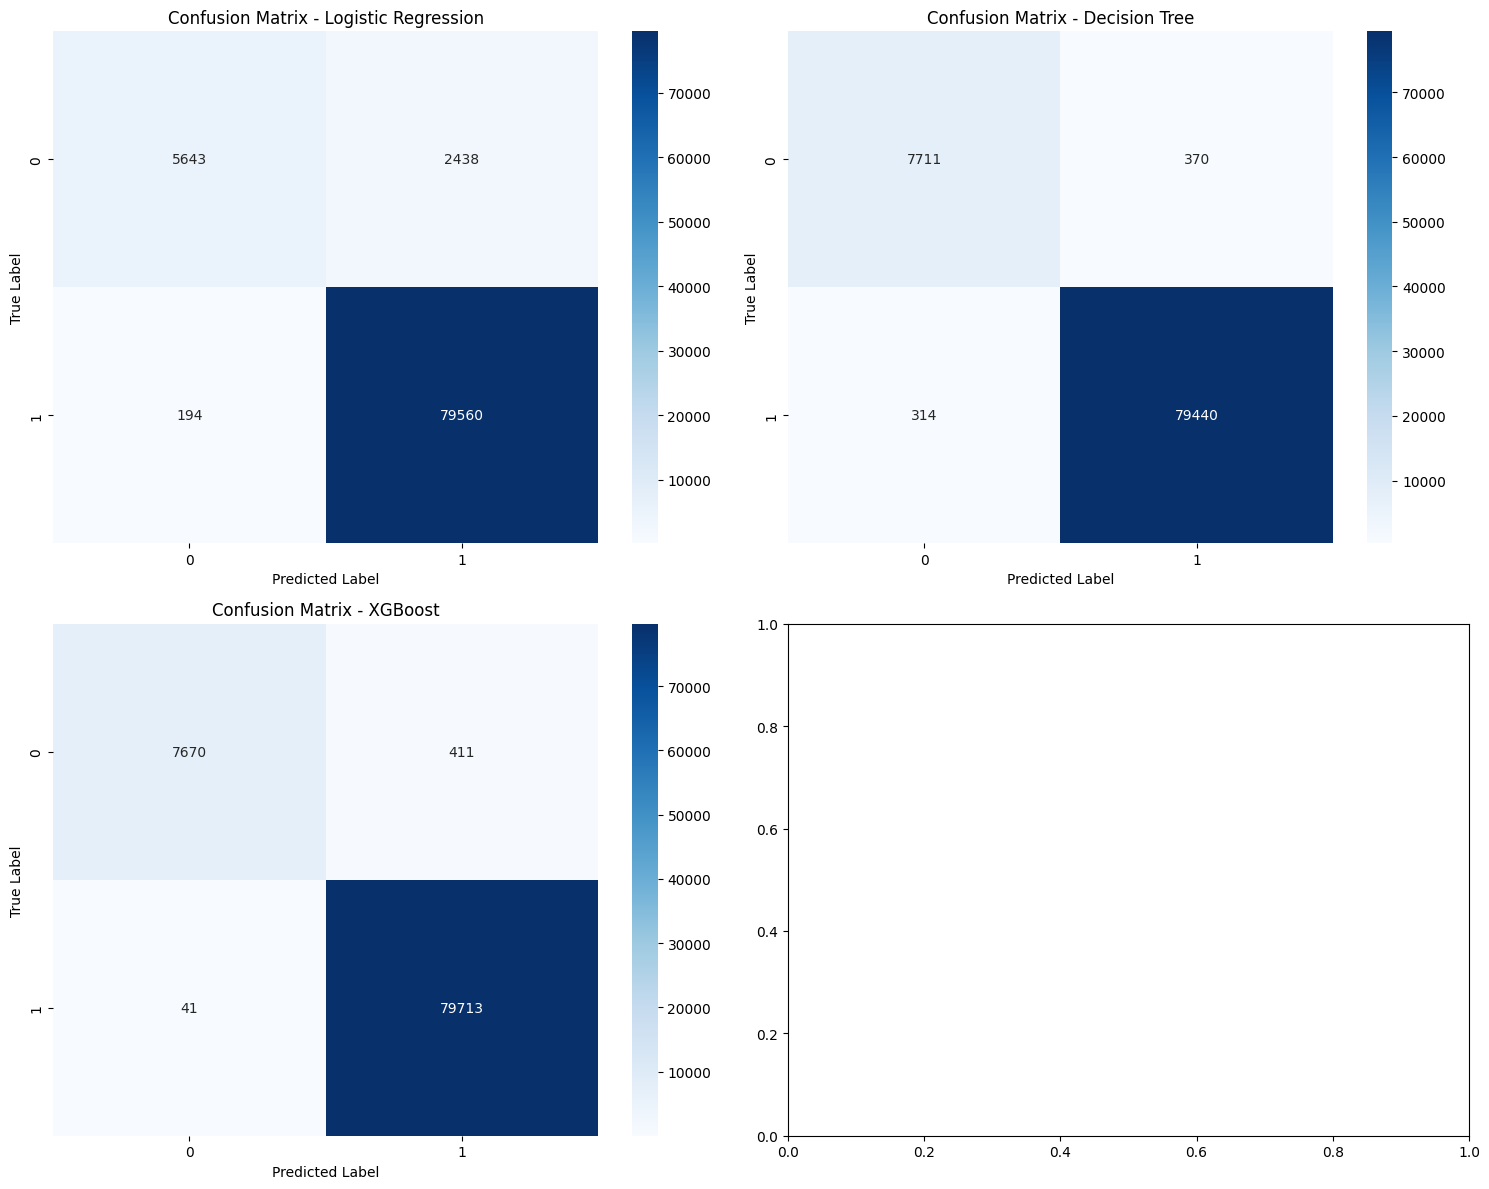

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    sns.heatmap(result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[idx])
    axes[idx].set_title(f"Confusion Matrix - {name}")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show() 